# DS Lab Assignment 4 — Data Preprocessing
### Topics: Normalization, Standardization, Categorical Encoding, Missing Value Imputation

**Name**: Debarun Ghosh \
**Student ID**: 25MDA294 \
**Date**: 11 May 2026

## Part 1 — Wine Dataset: Normalization & Standardization
**Dataset:** 178 samples, 13 features, 3 classes (no missing values)  
**Task:** Apply Min-Max Normalization and Z-score Standardization on columns 1–3 (Alcohol, Malic acid, Ash)

### 1.1 Load the Wine Dataset
We load the CSV (no header row) and assign column names based on the UCI Wine dataset specification.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

col_names = [
    'Class_Label', 'Alcohol', 'Malic_Acid', 'Ash',
    'Alcalinity_of_Ash', 'Magnesium', 'Total_Phenols',
    'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins',
    'Color_Intensity', 'Hue', 'OD280_OD315', 'Proline'
]

# why specific column names? Because the dataset doesn't have a header row, so we need to provide column names explicitly when loading the data. This allows us to work with the DataFrame using meaningful column names instead of default numeric indices.

wine = pd.read_csv('assgn4-data/wine_data.csv', header=None, names=col_names)
print("Shape:", wine.shape)
wine.head()

Shape: (178, 14)


,Class_Label,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### 1.2 Min-Max Normalization (columns 1–3)
Min-Max Normalization rescales each feature to the range [0, 1] using the formula:  
`X_norm = (X - X_min) / (X_max - X_min)`  
This is useful when the algorithm requires bounded input (e.g., neural networks).

In [ ]:
from sklearn.preprocessing import MinMaxScaler

target_cols = ['Alcohol', 'Malic_Acid', 'Ash']

scaler_minmax = MinMaxScaler()
wine_normalized = wine.copy()
wine_normalized[target_cols] = scaler_minmax.fit_transform(wine[target_cols])

# wine_normalized[target_cols] now contains the normalized values for the specified columns, scaled to a range of [0, 1]. The minimum value in each column will be transformed to 0 and the maximum value will be transformed to 1 after this transformation.

print("Original statistics:")
print(wine[target_cols].describe().round(4))
print("\nAfter Min-Max Normalization:")
print(wine_normalized[target_cols].describe().round(4))

Original statistics:
        Alcohol  Malic_Acid       Ash
count  178.0000    178.0000  178.0000
mean    13.0006      2.3363    2.3665
std      0.8118      1.1171    0.2743
min     11.0300      0.7400    1.3600
25%     12.3625      1.6025    2.2100
50%     13.0500      1.8650    2.3600
75%     13.6775      3.0825    2.5575
max     14.8300      5.8000    3.2300

After Min-Max Normalization:
        Alcohol  Malic_Acid       Ash
count  178.0000    178.0000  178.0000
mean     0.5186      0.3155    0.5382
std      0.2136      0.2208    0.1467
min      0.0000      0.0000    0.0000
25%      0.3507      0.1705    0.4545
50%      0.5316      0.2223    0.5348
75%      0.6967      0.4629    0.6404
max      1.0000      1.0000    1.0000


### 1.3 Z-score Standardization (columns 1–3)
Z-score Standardization transforms each feature to have **mean = 0** and **standard deviation = 1** using:  
`X_std = (X - μ) / σ`  
This is preferred when the data roughly follows a Gaussian distribution or when outliers are present.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
wine_standardized = wine.copy()
wine_standardized[target_cols] = scaler_std.fit_transform(wine[target_cols]) # Standardize the target columns using Z-score standardization

# wine_standardized[target_cols] now contains the standardized values for the specified columns. The mean of these columns will be approximately 0 and the standard deviation will be approximately 1 after this transformation.

print("After Z-score Standardization:")
print(wine_standardized[target_cols].describe().round(4))

After Z-score Standardization:
        Alcohol  Malic_Acid       Ash
count  178.0000    178.0000  178.0000
mean    -0.0000     -0.0000   -0.0000
std      1.0028      1.0028    1.0028
min     -2.4342     -1.4330   -3.6792
25%     -0.7882     -0.6587   -0.5721
50%      0.0610     -0.4231   -0.0238
75%      0.8361      0.6698    0.6981
max      2.2598      3.1092    3.1563


### 1.4 Visual Comparison
We plot side-by-side histograms of the original, normalized, and standardized distributions for each of the three columns to observe the effect of each scaling technique.

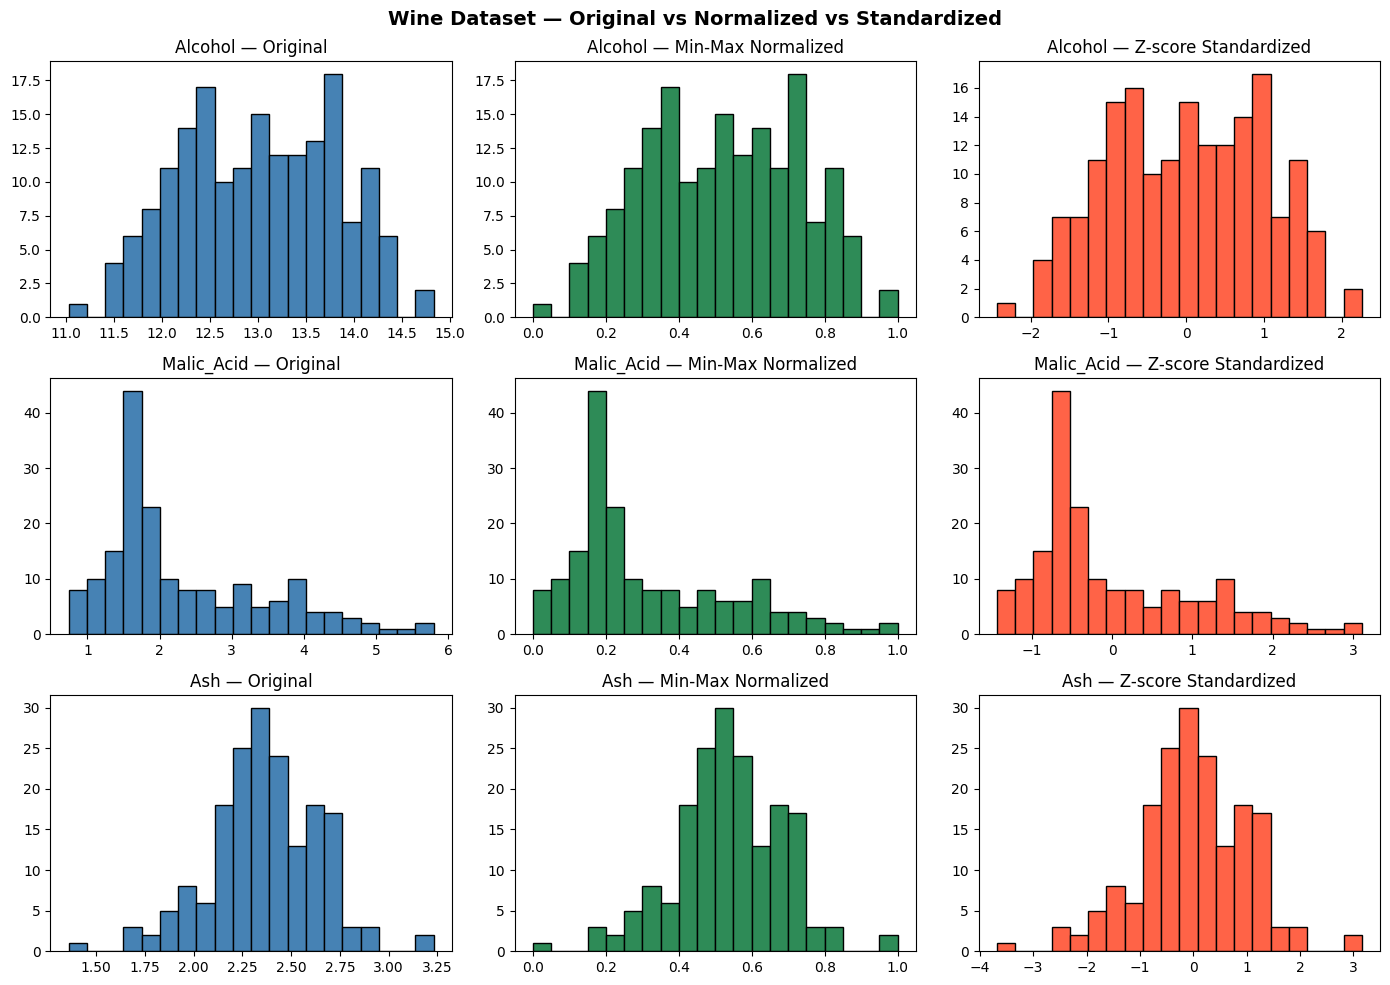

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Wine Dataset — Original vs Normalized vs Standardized', fontsize=14, fontweight='bold')

for i, col in enumerate(target_cols):  # the use of enumerate allows us to loop through the target columns while keeping track of the index 'i' for plotting
    axes[i, 0].hist(wine[col], bins=20, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} — Original')

    axes[i, 1].hist(wine_normalized[col], bins=20, color='seagreen', edgecolor='black')
    axes[i, 1].set_title(f'{col} — Min-Max Normalized')

    axes[i, 2].hist(wine_standardized[col], bins=20, color='tomato', edgecolor='black')
    axes[i, 2].set_title(f'{col} — Z-score Standardized')

plt.tight_layout()
plt.show()

### Outcome Analysis — Part 1

**Min-Max Normalization:**
- All three columns now bounded in **[0, 1]** — confirmed by min = 0.0, max = 1.0.
- `Alcohol` mean shifted from 13.0 → 0.52; `Malic_Acid` from 2.34 → 0.32; `Ash` from 2.37 → 0.54.
- Distribution **shape is fully preserved** — only the x-axis scale changes (visible in histograms).
- `Malic_Acid` retains its right skew; `Ash` retains its near-normal shape — Min-Max does **not** correct skewness.

**Z-score Standardization:**
- Mean ≈ **0** and std ≈ **1** for all three columns as expected.
- `Alcohol` spans **[-2.43, +2.26]** — tight and nearly symmetric.
- `Malic_Acid` spans **[-1.43, +3.11]** — long right tail confirms heavy right skew; outliers appear as large positive z-scores.
- `Ash` spans **[-3.68, +3.16]** — widest standardized range despite the smallest original std (0.27), due to a few extreme values.

**Key Takeaway:** Both methods only **rescale** data without altering its shape or correcting skewness. Min-Max is sensitive to outliers (one extreme value compresses the rest); Z-score exposes outliers as high-magnitude z-scores instead of hiding them.

---
## Part 2 — Heart Disease UCI Dataset: Categorical Encoding
**Dataset:** 14 attributes including age, sex, chest pain type, etc.  
**Task:** Identify all categorical/discrete columns and encode them using Label Encoding and One-Hot Encoding.

### 2.1 Load the Heart Disease Dataset
We load the dataset and inspect the data types and unique value counts to identify categorical and discrete columns.

In [5]:
heart = pd.read_csv('assgn4-data/heart_disease_uci.csv')
print("Shape:", heart.shape)
print("\nData types:")
print(heart.dtypes)
heart.head()

Shape: (920, 16)

Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 2.2 Identify Categorical and Discrete Columns
We separate columns by type:
- **Categorical (string/object):** sex, dataset, cp, restecg, slope, thal
- **Boolean (True/False):** fbs, exang — treated as binary categorical
- **Discrete (integer with few unique values):** ca, num (target variable)

In [ ]:
categorical_cols = heart.select_dtypes(include=['object', 'str']).columns.tolist()  # categorical_cols contains columns with data type 'object' or 'str', which typically represent categorical variables in a DataFrame.
bool_cols = heart.select_dtypes(include=['bool']).columns.tolist() # bool_cols contains columns with boolean data type, which represent True/False values in the DataFrame.

# Discrete numeric columns with few unique values (excluding id)
# numeric_cols contains columns with numeric data types, and discrete_cols filters those to include only columns that have 10 or fewer unique values (indicating they are likely categorical in nature) and excludes the 'id' column which is typically a unique identifier and not a feature for analysis.
# discrete_cols will contain the names of numeric columns that are considered discrete based on the number of unique values they have, which can be useful for understanding the structure of the dataset and for deciding how to handle these columns in analysis or modeling.
numeric_cols = heart.select_dtypes(include=['number']).columns.tolist() 
discrete_cols = [c for c in numeric_cols if heart[c].nunique() <= 10 and c != 'id']

print("Categorical (object) columns:", categorical_cols)
print("Boolean columns:", bool_cols)
print("Discrete numeric columns:", discrete_cols)

print("\nUnique values per categorical column:")
for col in categorical_cols:
    print(f"  {col}: {heart[col].unique()}")

Categorical (object) columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Boolean columns: []
Discrete numeric columns: ['ca', 'num']

Unique values per categorical column:
  sex: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
  dataset: <StringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str
  cp: <StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str
  fbs: [True False nan]
  restecg: <StringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str
  exang: [False True nan]
  slope: <StringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str
  thal: <StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str


### 2.3 Label Encoding
Label Encoding maps each unique category to an integer (0, 1, 2, ...). It is suitable for **ordinal** categorical features or tree-based models, where order can be exploited. We apply it to all categorical and boolean columns.

In [ ]:
from sklearn.preprocessing import LabelEncoder # For encoding categorical variables 

heart_label_enc = heart.copy()
le = LabelEncoder() # Initialize LabelEncoder

encode_cols = categorical_cols + bool_cols  # Combine categorical and boolean columns for encoding
for col in encode_cols:                     
    heart_label_enc[col] = le.fit_transform(heart_label_enc[col].astype(str))  # Encode categorical and boolean columns using LabelEncoder

# heart_label_enc[col] contains the label encoded values for the column 'col' after applying LabelEncoder. The .astype(str) ensures that all values are treated as strings, which is necessary for LabelEncoder to work correctly, especially for boolean columns.

print("Label Encoded columns:")
heart_label_enc[encode_cols].head(10) # Displaying first 10 rows of encoded columns for verification

Label Encoded columns:


,sex,dataset,cp,fbs,restecg,exang,slope,thal
0,1,0,3,1,0,0,0,0
1,1,0,0,0,0,1,1,1
2,1,0,0,0,0,1,1,2
3,1,0,2,0,1,0,0,1
4,0,0,1,0,0,0,2,1
5,1,0,1,0,1,0,2,1
6,0,0,0,0,0,0,0,1
7,0,0,0,0,1,1,2,1
8,1,0,0,0,0,0,1,2
9,1,0,0,1,0,1,0,2


### 2.4 One-Hot Encoding
One-Hot Encoding creates a new binary column for each unique category. It avoids the implicit ordinal relationship introduced by Label Encoding and is preferred for **nominal** features used in linear models. We apply it to the string categorical columns.

In [ ]:
heart_ohe = pd.get_dummies(heart, columns=categorical_cols, drop_first=False) # get_dummies for OHE, keep all categories (drop_first=False)

print(f"Shape before OHE: {heart.shape}")
print(f"Shape after OHE:  {heart_ohe.shape}")
heart_ohe.head()

Shape before OHE: (920, 16)
Shape after OHE:  (920, 31)


,id,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Female,sex_Male,...,restecg_normal,restecg_st-t abnormality,exang_False,exang_True,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,150.0,2.3,0.0,0,False,True,...,False,False,True,False,True,False,False,True,False,False
1,2,67,160.0,286.0,108.0,1.5,3.0,2,False,True,...,False,False,False,True,False,True,False,False,True,False
2,3,67,120.0,229.0,129.0,2.6,2.0,1,False,True,...,False,False,False,True,False,True,False,False,False,True
3,4,37,130.0,250.0,187.0,3.5,0.0,0,False,True,...,True,False,True,False,True,False,False,False,True,False
4,5,41,130.0,204.0,172.0,1.4,0.0,0,True,False,...,False,False,True,False,False,False,True,False,True,False


### 2.5 Value Counts of Key Categorical Columns
We visualize the distribution of the most important categorical features to understand class imbalance before encoding.

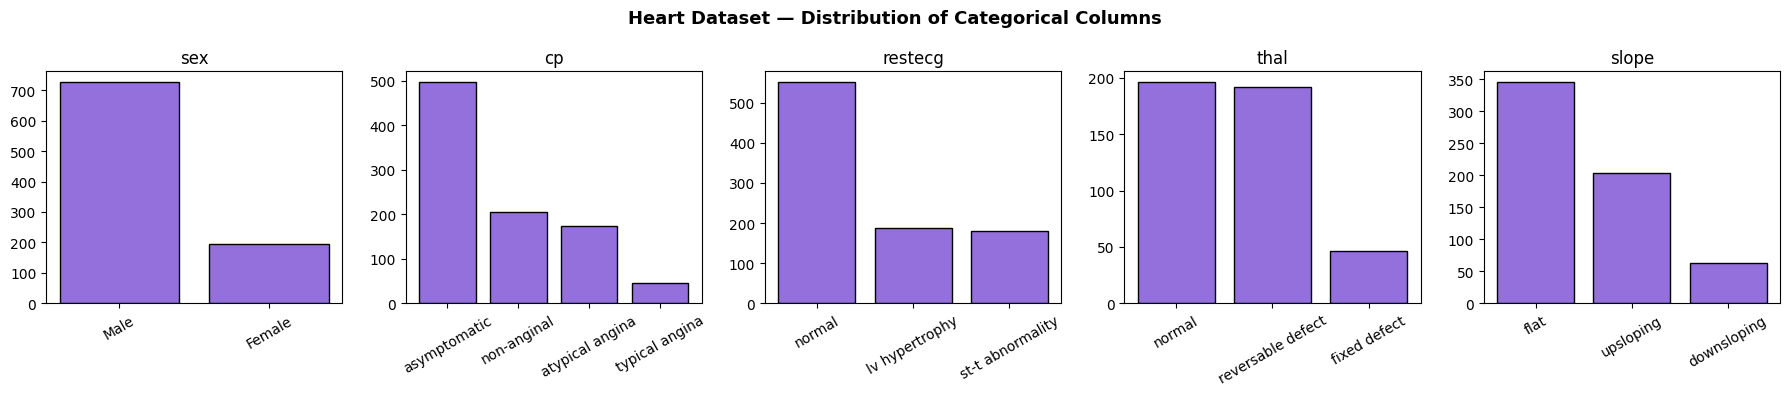

In [9]:
plot_cols = ['sex', 'cp', 'restecg', 'thal', 'slope']
fig, axes = plt.subplots(1, len(plot_cols), figsize=(18, 4))
fig.suptitle('Heart Dataset — Distribution of Categorical Columns', fontsize=13, fontweight='bold')

for ax, col in zip(axes, plot_cols):
    counts = heart[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color='mediumpurple', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Outcome Analysis — Part 2

**Identified Column Types:**
- **Categorical (str/object):** `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal` — 8 columns. Note: `fbs` and `exang` are stored as `object` (True/False + NaN mixed) rather than pure bool.
- **Boolean columns:** None detected — `fbs` and `exang` were read as `object` due to mixed NaN values.
- **Discrete numeric:** `ca` (vessel count 0–3) and `num` (disease severity 0–4, the target label).

**Label Encoding:**
- All 8 columns mapped to integers: e.g., `sex` → Male=1, Female=0; `cp` → asymptomatic=0, atypical angina=1, non-anginal=2, typical angina=3; `slope` → downsloping=0, flat=1, upsloping=2.
- NaN values were cast to the string `"nan"` before encoding — they get their own label. This is acceptable for now but would need a separate strategy in a real pipeline.
- Compact representation, but imposes a false ordinal relationship — `thal`: fixed defect=0 < normal=1 < reversable defect=2 has no real numeric meaning.

**One-Hot Encoding:**
- Shape expanded from **16 → 31 columns** (+15 binary indicator columns across 8 categorical features).
- Each category gets its own column: `sex_Male`, `sex_Female`, `cp_asymptomatic`, `thal_normal`, etc.
- Eliminates ordinal assumptions — each category is treated independently with a 0/1 flag.

**Distribution Insights (bar charts):**
- `sex`: heavily imbalanced — ~77% Male (~720), ~23% Female (~200). Models trained on this may be biased.
- `cp`: `asymptomatic` dominates (~500/920); `typical angina` is rare (~50) — despite being the "classic" heart disease symptom.
- `restecg`: `normal` most common (~550); `lv hypertrophy` and `st-t abnormality` roughly equal (~200 each).
- `thal`: `normal` and `reversable defect` nearly equal (~200 each); `fixed defect` rare (~50).
- `slope`: `flat` is the most frequent ST slope (~350), `upsloping` (~210), `downsloping` rare (~60).

**Key Takeaway:** Label Encoding is compact but risks misleading ordinal relationships for nominal features; One-Hot Encoding is semantically correct for nominal data at the cost of higher dimensionality (16→31 columns). The strong class imbalances in `sex` and `cp` are worth noting for any downstream modelling.

---
## Part 3 — Weather Australia Dataset: Missing Value Imputation
**Dataset:** Daily weather observations across Australia with many NA values.  
**Task:** Find columns with NAs, compute missing ratios, impute using mean (numeric), median (numeric with outliers), and mode (categorical). Visualize before and after.

### 3.1 Load the Weather Australia Dataset
We load the dataset and display its shape, columns, and data types to understand what we are working with.

In [10]:
weather = pd.read_csv('assgn4-data/weatherAUS.csv')
print("Shape:", weather.shape)
print("\nData types:")
print(weather.dtypes)
weather.head()

Shape: (142193, 24)

Data types:
Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RISK_MM          float64
RainTomorrow         str
dtype: object


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


### 3.2 Identify Missing Values and Compute Missing Ratio
We count the number of missing values (NaN) in each column and compute the missing ratio as a percentage. This helps decide which columns need imputation and which strategy to use.

In [ ]:
missing_count = weather.isnull().sum()                    # Count of missing values per column
missing_ratio = (weather.isnull().mean() * 100).round(2)  # Calculate missing ratio as percentage and round to 2 decimal places

missing_df = pd.DataFrame({  # Create a DataFrame to summarize missing value information
    'Missing Count': missing_count,
    'Missing Ratio (%)': missing_ratio,
    'Dtype': weather.dtypes
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Ratio (%)', ascending=False)  # Filter to show only columns with missing values and sort by ratio
print(f"Columns with missing values: {len(missing_df)}")
missing_df

Columns with missing values: 20


,Missing Count,Missing Ratio (%),Dtype
Sunshine,67816,47.69,float64
Evaporation,60843,42.79,float64
Cloud3pm,57094,40.15,float64
Cloud9am,53657,37.74,float64
Pressure9am,14014,9.86,float64
Pressure3pm,13981,9.83,float64
WindDir9am,10013,7.04,str
WindGustDir,9330,6.56,str
WindGustSpeed,9270,6.52,float64
WindDir3pm,3778,2.66,str


### 3.3 Visualize Missing Value Ratios
A horizontal bar chart gives a clear view of how much data is missing per column, helping prioritize the imputation strategy.

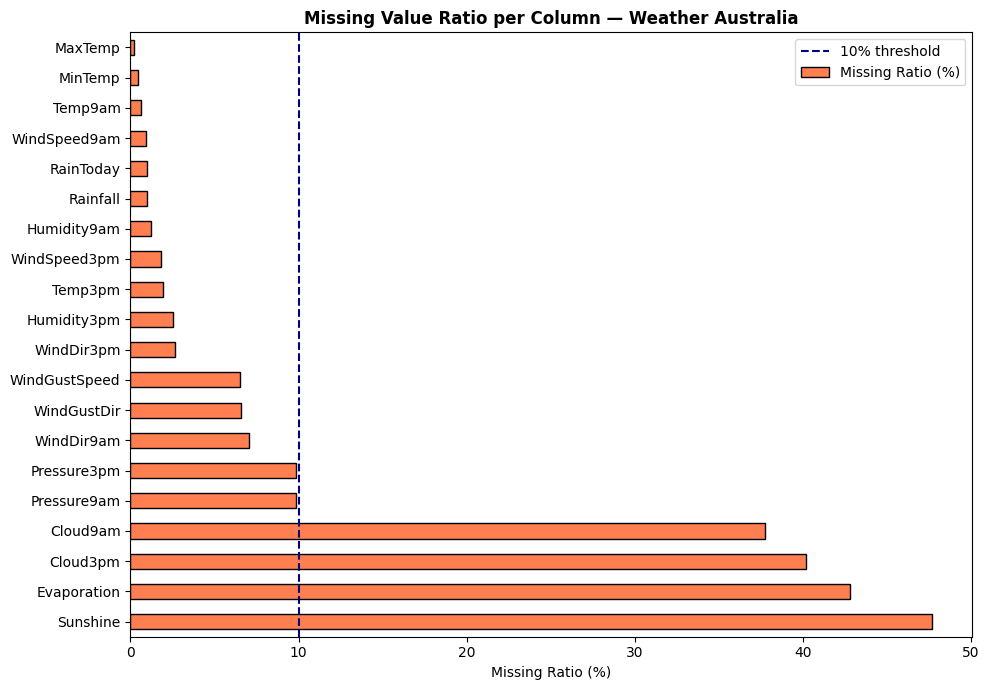

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
missing_df['Missing Ratio (%)'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Missing Ratio (%)')
ax.set_title('Missing Value Ratio per Column — Weather Australia', fontweight='bold')
ax.axvline(x=10, color='navy', linestyle='--', label='10% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Imputation Strategy
We apply different imputation strategies based on column type:
- **Mean imputation** — for numeric columns with roughly symmetric distributions (no heavy outliers)
- **Median imputation** — for numeric columns with skewed distributions or outliers (robust to extremes)
- **Mode imputation** — for categorical/object columns (most frequent value)

We use a simple skewness threshold: if `|skewness| > 1` use median, else use mean.

In [ ]:
weather_imputed = weather.copy()

mean_imputed = []     # To track columns imputed with mean
median_imputed = []   # To track columns imputed with median
mode_imputed = []     # To track columns imputed with mode (for categorical and highly skewed numeric columns)

cols_with_na = missing_df.index.tolist()

for col in cols_with_na:
    if not pd.api.types.is_numeric_dtype(weather[col]):
        fill_val = weather[col].mode()[0]
        weather_imputed[col] = weather_imputed[col].fillna(fill_val)  # Impute categorical columns with mode 
        mode_imputed.append(col)
    else:
        skewness = weather[col].skew()
        if abs(skewness) > 1:
            fill_val = weather[col].median()
            weather_imputed[col] = weather_imputed[col].fillna(fill_val)  # Impute highly skewed numeric columns with median
            median_imputed.append(col)
        else:
            fill_val = weather[col].mean()
            weather_imputed[col] = weather_imputed[col].fillna(fill_val)  # Impute numeric columns with mean
            mean_imputed.append(col)

print("Mean imputed columns:  ", mean_imputed)
print("Median imputed columns:", median_imputed)
print("Mode imputed columns:  ", mode_imputed)
print(f"\nRemaining missing values after imputation: {weather_imputed.isnull().sum().sum()}")

Mean imputed columns:   ['Sunshine', 'Cloud3pm', 'Cloud9am', 'Pressure9am', 'Pressure3pm', 'WindGustSpeed', 'Humidity3pm', 'Temp3pm', 'WindSpeed3pm', 'Humidity9am', 'WindSpeed9am', 'Temp9am', 'MinTemp', 'MaxTemp']
Median imputed columns: ['Evaporation', 'Rainfall']
Mode imputed columns:   ['WindDir9am', 'WindGustDir', 'WindDir3pm', 'RainToday']

Remaining missing values after imputation: 0


### 3.5 Observe Changes After Imputation
We compare the distribution statistics (mean, std, min, max) of a few key numeric columns before and after imputation to confirm that the imputation did not significantly distort the data.

In [ ]:
observe_cols = (mean_imputed + median_imputed)[:5]  # Show up to 5 columns imputed with mean/median for comparison

print("=== Before Imputation ===")
print(weather[observe_cols].describe().round(3))
print("\n=== After Imputation ===")
print(weather_imputed[observe_cols].describe().round(3))

=== Before Imputation ===
        Sunshine   Cloud3pm   Cloud9am  Pressure9am  Pressure3pm
count  74377.000  85099.000  88536.000   128179.000   128212.000
mean       7.625      4.503      4.437     1017.654     1015.258
std        3.782      2.721      2.887        7.105        7.037
min        0.000      0.000      0.000      980.500      977.100
25%        4.900      2.000      1.000     1012.900     1010.400
50%        8.500      5.000      5.000     1017.600     1015.200
75%       10.600      7.000      7.000     1022.400     1020.000
max       14.500      9.000      9.000     1041.000     1039.600

=== After Imputation ===
         Sunshine    Cloud3pm    Cloud9am  Pressure9am  Pressure3pm
count  142193.000  142193.000  142193.000   142193.000   142193.000
mean        7.625       4.503       4.437     1017.654     1015.258
std         2.735       2.105       2.278        6.746        6.682
min         0.000       0.000       0.000      980.500      977.100
25%         7.625      

### 3.6 Visualize Distribution Before and After Imputation
Box plots let us see how the spread and central tendency of each column changed after imputation. An ideal imputation should preserve the overall distribution shape.

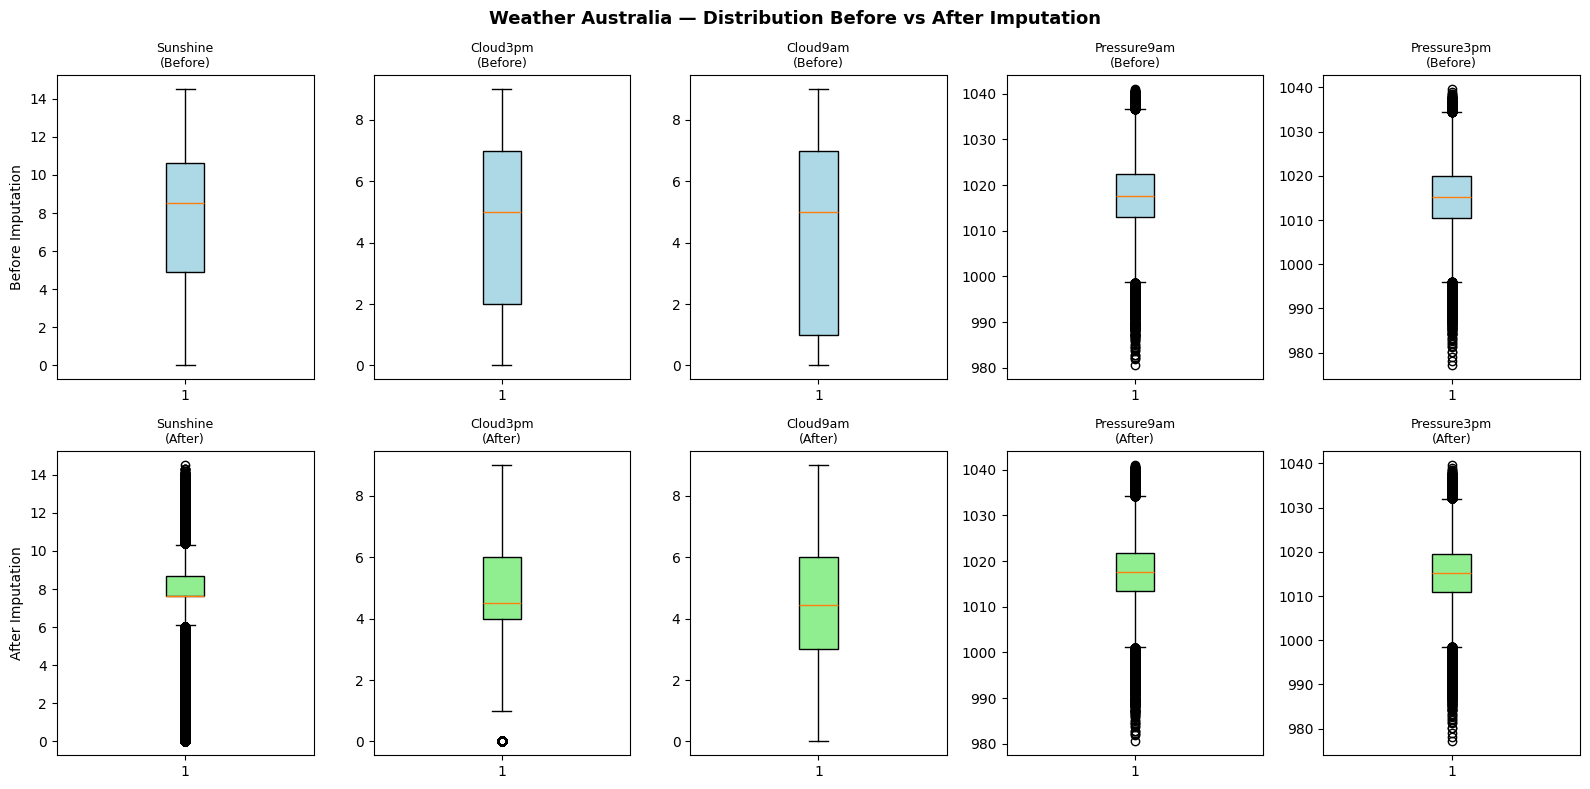

In [15]:
fig, axes = plt.subplots(2, len(observe_cols), figsize=(16, 8))
fig.suptitle('Weather Australia — Distribution Before vs After Imputation', fontsize=13, fontweight='bold')

for i, col in enumerate(observe_cols):
    axes[0, i].boxplot(weather[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[0, i].set_title(f'{col}\n(Before)', fontsize=9)

    axes[1, i].boxplot(weather_imputed[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[1, i].set_title(f'{col}\n(After)', fontsize=9)

axes[0, 0].set_ylabel('Before Imputation')
axes[1, 0].set_ylabel('After Imputation')
plt.tight_layout()
plt.show()

### 3.7 Histogram Comparison for a High-Missing Column
We focus on `Evaporation` (one of the columns with the highest missing ratio) and overlay the histograms before and after imputation to observe how the fill affects the frequency distribution.

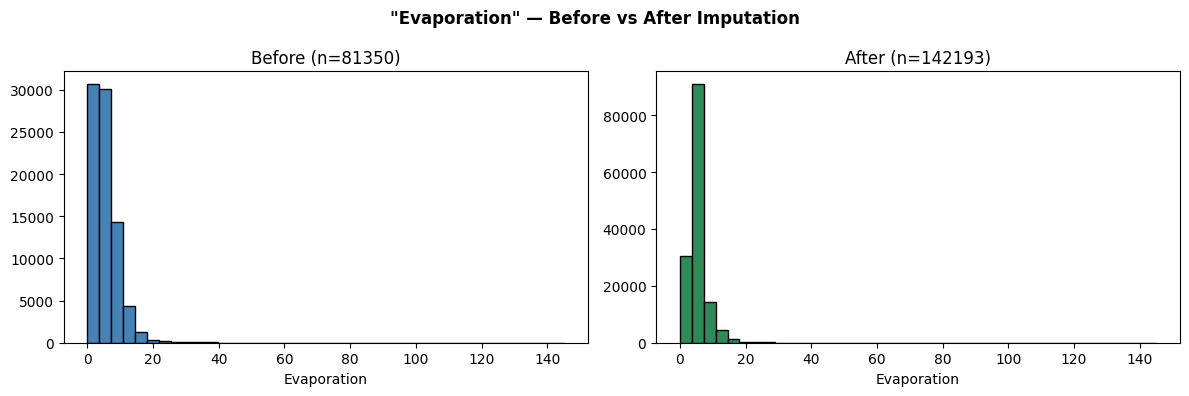

In [16]:
focus_col = 'Evaporation'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'"{focus_col}" — Before vs After Imputation', fontweight='bold')

axes[0].hist(weather[focus_col].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title(f'Before (n={weather[focus_col].notna().sum()})')
axes[0].set_xlabel(focus_col)

axes[1].hist(weather_imputed[focus_col], bins=40, color='seagreen', edgecolor='black')
axes[1].set_title(f'After (n={weather_imputed[focus_col].notna().sum()})')
axes[1].set_xlabel(focus_col)

plt.tight_layout()
plt.show()

### Outcome Analysis — Part 3

**Missing Value Summary:**
- **20 out of 24 columns** had missing values — a heavily incomplete dataset.
- Top 4 columns had critical missingness: `Sunshine` (47.69%), `Evaporation` (42.79%), `Cloud3pm` (40.15%), `Cloud9am` (37.74%) — nearly half the data missing in these columns.
- 4 columns (`Pressure9am`, `Pressure3pm`, `WindDir9am`, `WindGustDir`) crossed the 10% threshold; the rest had < 3% missing.

**Imputation Strategy Applied:**
- **Mean (14 columns):** `Sunshine`, `Cloud3pm`, `Cloud9am`, `Pressure9am/3pm`, `WindGustSpeed`, `Humidity`, `Temp`, `WindSpeed`, `MinTemp`, `MaxTemp` — symmetric enough that mean is a safe fill.
- **Median (2 columns):** `Evaporation`, `Rainfall` — right-skewed distributions (heavy rainfall events pull the mean up); median is more robust.
- **Mode (4 columns):** `WindDir9am`, `WindGustDir`, `WindDir3pm`, `RainToday` — categorical/string columns filled with the most frequent direction or Yes/No value.
- **Remaining missing after imputation: 0** ✓ — all gaps fully resolved.

**Statistical Changes After Imputation (describe comparison):**
- **Mean unchanged** for all 5 observed columns — mean imputation by definition preserves the column mean.
- **Std decreased** noticeably: `Sunshine` 3.78 → 2.74, `Cloud3pm` 2.72 → 2.11, `Cloud9am` 2.89 → 2.28 — adding many identical fill values compresses variance artificially.
- **25th and 50th percentiles shifted** toward the mean: `Sunshine` 25% went from 4.9 → 7.6 (the fill value itself), confirming the large spike at the mean in the distribution.

**Box Plot Observations:**
- After imputation, IQR (box size) narrows for all columns — the distribution becomes more concentrated around the center due to the large number of identical fill values injected.
- Outlier whiskers are largely unchanged — extreme values are unaffected by mean/median fill.

**Evaporation Histogram (Median Imputation):**
- Before: n = 81,350 (of 142,193); right-skewed with a peak near 0–5 mm.
- After: n = 142,193; the first bin spikes dramatically (~90,000) because all 60,843 missing values were filled with the same median value (~4.8 mm), creating an artificial concentration.
- The right tail shape is preserved, but the peak is inflated — a known limitation of single-value imputation on highly skewed columns.

**Key Takeaway:** Mean/median imputation is simple and effective for low-missingness columns but distorts distributions when missingness is high (>40%). For `Sunshine`, `Evaporation`, and cloud columns, more advanced methods (KNN imputation, iterative imputation) would better preserve natural variability.